# German Credit Data

## Data Dictionary (Grouped by Feature Type)

This section provides an overview of all variables in the South German Credit dataset, grouped by their statistical nature.  
The coding schemes follow the original dataset documentation.

---

### Numerical Features (Quantitative)

**laufzeit** (`duration`)  
- Credit duration in months  

**hoehe** (`amount`)  
- Credit amount in Deutsche Mark (DM)  
- Result of a monotonic transformation (exact transformation unknown)  

**alter** (`age`)  
- Age of the debtor in years  

---

### Ordinal Features (Ordered, Discretized Quantitative)

**laufkont** (`status`) — Status of checking account  
- 1 : no checking account  
- 2 : balance < 0 DM  
- 3 : 0 ≤ balance < 200 DM  
- 4 : balance ≥ 200 DM or salary for at least 1 year  

**beszeit** (`employment_duration`) — Employment duration  
- 1 : unemployed  
- 2 : < 1 year  
- 3 : 1 ≤ … < 4 years  
- 4 : 4 ≤ … < 7 years  
- 5 : ≥ 7 years  

**rate** (`installment_rate`) — Installment rate (% of disposable income)  
- 1 : ≥ 35%  
- 2 : 25% ≤ … < 35%  
- 3 : 20% ≤ … < 25%  
- 4 : < 20%  

**wohnzeit** (`present_residence`) — Length of residence  
- 1 : < 1 year  
- 2 : 1 ≤ … < 4 years  
- 3 : 4 ≤ … < 7 years  
- 4 : ≥ 7 years  

**verm** (`property`) — Most valuable property  
- 1 : unknown / no property  
- 2 : car or other  
- 3 : building society savings agreement / life insurance  
- 4 : real estate  

**bishkred** (`number_credits`) — Number of credits at this bank  
- 1 : 1  
- 2 : 2–3  
- 3 : 4–5  
- 4 : ≥ 6  

**beruf** (`job`) — Job quality  
- 1 : unemployed / unskilled (non-resident)  
- 2 : unskilled (resident)  
- 3 : skilled employee / official  
- 4 : manager / self-employed / highly qualified employee  

---

### Categorical Features (Nominal, Unordered)

**moral** (`credit_history`) — Credit history  
- 0 : delay in paying off in the past  
- 1 : critical account / other credits elsewhere  
- 2 : no credits taken or all credits paid back duly  
- 3 : existing credits paid back duly till now  
- 4 : all credits at this bank paid back duly  

**verw** (`purpose`) — Credit purpose  
- 0 : others  
- 1 : car (new)  
- 2 : car (used)  
- 3 : furniture / equipment  
- 4 : radio / television  
- 5 : domestic appliances  
- 6 : repairs  
- 7 : education  
- 8 : vacation  
- 9 : retraining  
- 10 : business  

**sparkont** (`savings`) — Savings account  
- 1 : unknown / no savings account  
- 2 : < 100 DM  
- 3 : 100 ≤ … < 500 DM  
- 4 : 500 ≤ … < 1000 DM  
- 5 : ≥ 1000 DM  

**famges** (`personal_status_sex`) — Personal status and sex (combined)  
- 1 : male, divorced / separated  
- 2 : female non-single or male single  
- 3 : male, married / widowed  
- 4 : female, single  

**buerge** (`other_debtors`) — Other debtors or guarantor  
- 1 : none  
- 2 : co-applicant  
- 3 : guarantor  

**weitkred** (`other_installment_plans`) — Other installment plans  
- 1 : bank  
- 2 : stores  
- 3 : none  

**wohn** (`housing`) — Housing type  
- 1 : for free  
- 2 : rent  
- 3 : own  

---

### Binary Features

**pers** (`people_liable`) — Number of people liable for maintenance  
- 1 : 3 or more  
- 2 : 0 to 2  

**telef** (`telephone`) — Telephone registered in debtor’s name  
- 1 : no  
- 2 : yes  

**gastarb** (`foreign_worker`) — Foreign worker status  
- 1 : yes  
- 2 : no  

---

### Target Variable

**default** (derived from `kredit`) — Credit risk outcome  
- `default = 1` : bad credit / default  
- `default = 0` : good credit / non-default  

The original variable `kredit` (`0 = bad`, `1 = good`) was transformed and removed to avoid ambiguity and to align with standard credit-risk modeling conventions.


## Imports

In [6]:
# --- Standard libraries ---
import sys
import os

# Add project root to path so we can import config.py
sys.path.append("..")

# --- Third-party libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Project configuration ---
from config import (
    COLUMN_RENAME_MAP,
    NUMERICAL_FEATURES,
    ORDINAL_FEATURES,
    CATEGORICAL_FEATURES,
    BINARY_FEATURES
)

# Display settings (optional but nice for EDA)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")


## Read and show data

In [7]:
df = pd.read_csv("../data/raw/german_credit_data.csv")
df.head()


,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,wohnzeit,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,2,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,4,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,2,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,4,2,38,1,2,2,2,2,1,1,1


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   laufkont  1000 non-null   int64
 1   laufzeit  1000 non-null   int64
 2   moral     1000 non-null   int64
 3   verw      1000 non-null   int64
 4   hoehe     1000 non-null   int64
 5   sparkont  1000 non-null   int64
 6   beszeit   1000 non-null   int64
 7   rate      1000 non-null   int64
 8   famges    1000 non-null   int64
 9   buerge    1000 non-null   int64
 10  wohnzeit  1000 non-null   int64
 11  verm      1000 non-null   int64
 12  alter     1000 non-null   int64
 13  weitkred  1000 non-null   int64
 14  wohn      1000 non-null   int64
 15  bishkred  1000 non-null   int64
 16  beruf     1000 non-null   int64
 17  pers      1000 non-null   int64
 18  telef     1000 non-null   int64
 19  gastarb   1000 non-null   int64
 20  kredit    1000 non-null   int64
dtypes: int64(21)
memory usage: 164.2 KB


### Rename Columns

In [9]:
df = df.rename(columns=COLUMN_RENAME_MAP)
df.columns


Index(['status', 'duration', 'credit_history', 'purpose', 'amount', 'savings', 'employment_duration',
       'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'age',
       'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker',
       'kredit'],
      dtype='str')

### check label distribution

In [10]:
df["kredit"].value_counts()


kredit
1    700
0    300
Name: count, dtype: int64

### switch labels and check default rate

In [11]:
df["default"] = 1 - df["kredit"]

In [12]:
df["default"].value_counts()

default
0    700
1    300
Name: count, dtype: int64

In [13]:
default_rate = df["default"].mean()
print("default rate: " + str(default_rate))

default rate: 0.3


### drop misleading "kredit" column

In [14]:
df = df.drop(columns=["kredit"])

## Closer look at numerical features

In [15]:
df[["duration", "amount", "age"]].describe().T

,count,mean,std,min,25%,50%,75%,max
duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
amount,1000.0,3271.248,2822.751760,250.0,1365.5,2319.5,3972.25,18424.0
age,1000.0,35.542,11.352670,19.0,27.0,33.0,42.00,75.0


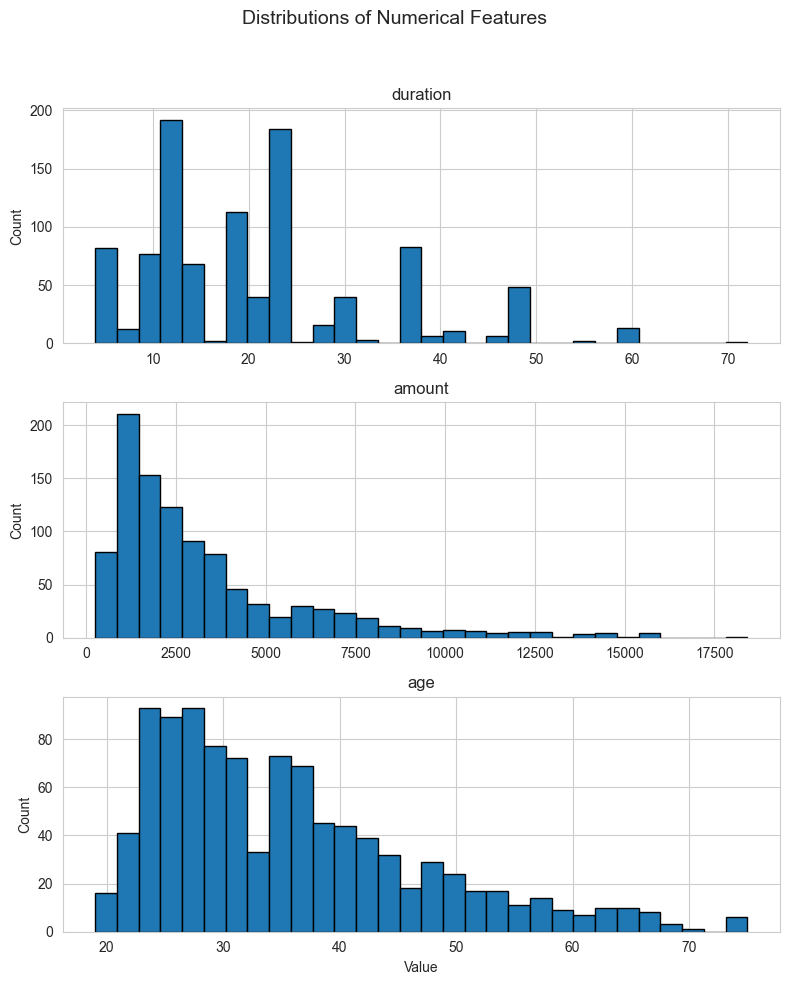

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 10))

for ax, col in zip(axes, ["duration", "amount", "age"]):
    ax.hist(df[col], bins=30, edgecolor="black")
    ax.set_title(col)
    ax.set_ylabel("Count")

axes[-1].set_xlabel("Value")

plt.suptitle("Distributions of Numerical Features", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # <-- leaves space at the top
plt.show()


duration: 
- Discrete peaks (12, 18, 24, 36, 48 months)
- Long right tail (up to 72 months)
- Not smooth → reflects real loan products
--> Treat as numeric, but expect non-linear risk effects


amount:
- Strong right skew
- Majority of loans are small
- Few very large loans (long tail)
--> Scaling required for log-reg, Log-transform may help later


age:
- Roughly bell-shaped with right tail
- Younger borrowers are more frequent
- No implausible values (19–75)
--> No cleaning needed


### Boxplots by default

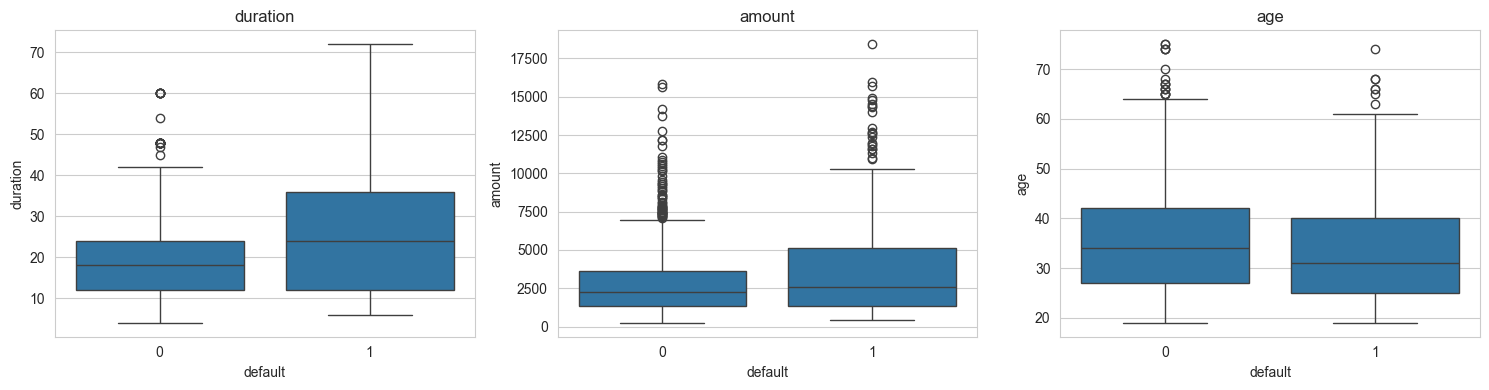

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, col in zip(axes, ["duration", "amount", "age"]):
    sns.boxplot(x="default", y=col, data=df, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


### Default rate by quantiles

In [18]:
for col in ["duration", "amount", "age"]:
    df[f"{col}_bin"] = pd.qcut(df[col], q=5, duplicates="drop")
    print(f"\nDefault rate by {col} quintiles:")
    print(df.groupby(f"{col}_bin")["default"].mean())



Default rate by duration quintiles:
duration_bin
(3.999, 12.0]    0.211699
(12.0, 15.0]     0.180556
(15.0, 24.0]     0.321534
(24.0, 30.0]     0.333333
(30.0, 72.0]     0.479769
Name: default, dtype: float64

Default rate by amount quintiles:
amount_bin
(249.999, 1262.0]    0.303483
(1262.0, 1906.8]     0.241206
(1906.8, 2852.4]     0.270000
(2852.4, 4720.0]     0.260000
(4720.0, 18424.0]    0.425000
Name: default, dtype: float64

Default rate by age quintiles:
age_bin
(18.999, 26.0]    0.393305
(26.0, 30.0]      0.317647
(30.0, 36.0]      0.256881
(36.0, 44.0]      0.264368
(44.0, 75.0]      0.251256
Name: default, dtype: float64


### Numerical Features and Default Risk

**Duration**
- Defaulters (`default = 1`) exhibit clearly longer loan durations, with higher medians and heavier upper tails.
- Default rates increase strongly and monotonically across duration quintiles, from approximately 18–21% for short loans to nearly 48% for long loans.
- Duration is a key risk driver; while a linear effect is plausible, some non-linearity is present and well-suited for tree-based models.

**Amount**
- Defaulters tend to have higher median loan amounts and a pronounced right tail.
- Default rates range from roughly 24–30% for lower and mid-range amounts, increasing to about 42.5% in the highest quintile.
- This indicates a clear tail-risk effect; scaling is required and a log-transformation may benefit logistic regression, while outliers appear informative.

**Age**
- Defaulters are slightly younger on average, although distributions overlap substantially.
- The highest default rate is observed for the youngest age group (≈39%), with risk decreasing and flattening beyond roughly 30–35 years.
- The relationship between age and default risk is non-linear; linear models may underfit this effect, whereas tree-based models can capture it more effectively.


## Closer look at ordinal features

In [19]:
# Ordinal features
ordinal_features = [
    "status",
    "employment_duration",
    "installment_rate",
    "present_residence",
    "property",
    "number_credits",
    "job"
]

# Helper function for pretty formatting
def pretty_ordinal_table(df_summary, n_obs):
    df_out = (
        df_summary
        .assign(
            default_rate=lambda x: (x["default_rate"] * 100).round(1),
            share=lambda x: (x["count"] / n_obs * 100).round(1)
        )
        .rename(
            columns={
                "count": "Count",
                "default_rate": "Default rate (%)",
                "share": "Share (%)"
            }
        )
    )
    df_out.index.name = "Level"
    return df_out


# Compute + display summaries
ordinal_summaries = {}

for col in ordinal_features:
    summary = (
        df
        .groupby(col)
        .agg(
            count=("default", "size"),
            default_rate=("default", "mean")
        )
    )

    ordinal_summaries[col] = summary

    print(f"\n=== {col} ===")
    display(pretty_ordinal_table(summary, len(df)))



=== status ===


,Count,Default rate (%),Share (%)
Level,,,
1,274,49.3,27.4
2,269,39.0,26.9
3,63,22.2,6.3
4,394,11.7,39.4



=== employment_duration ===


,Count,Default rate (%),Share (%)
Level,,,
1,62,37.1,6.2
2,172,40.7,17.2
3,339,30.7,33.9
4,174,22.4,17.4
5,253,25.3,25.3



=== installment_rate ===


...

,Count,Default rate (%),Share (%)
Level,,,
1,282,21.3,28.2
2,232,30.6,23.2
3,332,30.7,33.2
4,154,43.5,15.4



=== number_credits ===


,Count,Default rate (%),Share (%)
Level,,,
1,633,31.6,63.3
2,333,27.6,33.3
3,28,21.4,2.8
4,6,33.3,0.6



=== job ===


,Count,Default rate (%),Share (%)
Level,,,
1,22,31.8,2.2
2,200,28.0,20.0
3,630,29.5,63.0
4,148,34.5,14.8


### Ordinal Features: Predictive Power and Encoding Decision

**Status (checking account)**
- Exhibits a very strong and monotonic relationship with default risk, with default rates decreasing from approximately 49% for the worst status to about 12% for the best status.
- All levels are well populated (each ≈ 6–40% of the sample), making the observed risk gradient stable and reliable.
- **Encoding decision:** Keep as **ordinal**.

**Employment Duration**
- Default risk is higher for short employment durations and generally decreases with increasing job stability, with some non-monotonicity in the highest category.
- All levels have sufficient support (≥6% of observations), supporting a stable ordinal interpretation.
- **Encoding decision:** Keep as **ordinal**.

**Installment Rate**
- Default risk increases steadily with higher installment burdens, from roughly 25% to 33%.
- Category frequencies are well balanced, with no sparsity issues.
- **Encoding decision:** Keep as **ordinal**.

**Present Residence**
- Default rates are relatively stable across residence duration levels, with no clear monotonic pattern.
- All categories are reasonably populated, but predictive power is weak.
- **Encoding decision:** Keep as **ordinal** (weak effect, but no strong reason to reclassify).

**Property**
- Default rates increase with higher-coded categories, contradicting the assumed ordinal risk interpretation.
- Although category frequencies are adequate, the coding reflects asset *type* rather than a meaningful risk order.
- **Encoding decision:** Treat as **categorical** (not ordinal).

**Number of Credits**
- Displays a non-linear relationship, with lower risk in intermediate categories and higher risk for the highest category.
- Higher categories are sparsely populated (levels 3 and 4 together <4% of observations), making default rate estimates less stable.
- **Encoding decision:** Keep as **ordinal**, but interpret higher levels with caution and allow for non-linear effects in modeling.

**Job**
- Differences in default rates across job quality levels are modest and not strictly monotonic.
- Lower job categories are sparsely populated (e.g. level 1 ≈2%), which limits the reliability of level-specific default rates.
- **Encoding decision:** Keep as **ordinal**, but acknowledge weak predictive power and potential instability in lower-frequency levels.


## Closer look at categorical features

In [20]:
categorical_features = [
    "credit_history",
    "purpose",
    "savings",
    "personal_status_sex",
    "other_debtors",
    "other_installment_plans",
    "housing",
    "property"  # treat as categorical based on EDA
]

def pretty_cat_table(df_summary, n_obs, top_n=None):
    df_out = (
        df_summary
        .assign(
            default_rate=lambda x: (x["default_rate"] * 100).round(1),
            share=lambda x: (x["count"] / n_obs * 100).round(1)
        )
        .rename(
            columns={
                "count": "Count",
                "default_rate": "Default rate (%)",
                "share": "Share (%)"
            }
        )
        .sort_values("Count", ascending=False)
    )
    df_out.index.name = "Category"
    if top_n is not None:
        df_out = df_out.head(top_n)
    return df_out


categorical_summaries = {}

for col in categorical_features:
    summary = (
        df
        .groupby(col)
        .agg(
            count=("default", "size"),
            default_rate=("default", "mean")
        )
    )

    categorical_summaries[col] = summary

    print(f"\n=== {col} ===")
    display(pretty_cat_table(summary, len(df)))



=== credit_history ===


,Count,Default rate (%),Share (%)
Category,,,
2,530,31.9,53.0
4,293,17.1,29.3
3,88,31.8,8.8
1,49,57.1,4.9
0,40,62.5,4.0



=== purpose ===


,Count,Default rate (%),Share (%)
Category,,,
3,280,22.1,28.0
0,234,38.0,23.4
2,181,32.0,18.1
1,103,16.5,10.3
9,97,35.1,9.7
6,50,44.0,5.0
5,22,36.4,2.2
4,12,33.3,1.2
10,12,41.7,1.2



=== savings ===


...

,Count,Default rate (%),Share (%)
Category,,,
3,814,27.5,81.4
1,139,41.0,13.9
2,47,40.4,4.7



=== housing ===


,Count,Default rate (%),Share (%)
Category,,,
2,714,26.1,71.4
1,179,39.1,17.9
3,107,41.1,10.7



=== property ===


,Count,Default rate (%),Share (%)
Category,,,
3,332,30.7,33.2
1,282,21.3,28.2
2,232,30.6,23.2
4,154,43.5,15.4


In [21]:
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,default,duration_bin,amount_bin,age_bin
0,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,2,1,2,0,"(15.0, 24.0]","(249.999, 1262.0]","(18.999, 26.0]"
1,1,9,4,0,2799,1,3,2,3,1,2,1,36,3,1,2,3,1,1,2,0,"(3.999, 12.0]","(1906.8, 2852.4]","(30.0, 36.0]"
2,2,12,2,9,841,2,4,2,2,1,4,1,23,3,1,1,2,2,1,2,0,"(3.999, 12.0]","(249.999, 1262.0]","(18.999, 26.0]"
3,1,12,4,0,2122,1,3,3,3,1,2,1,39,3,1,2,2,1,1,1,0,"(3.999, 12.0]","(1906.8, 2852.4]","(36.0, 44.0]"
4,1,12,4,0,2171,1,3,4,3,1,4,2,38,1,2,2,2,2,1,1,0,"(3.999, 12.0]","(1906.8, 2852.4]","(36.0, 44.0]"


### Categorical (Nominal) Features: Predictive Power and Interpretation

**Credit History**
- Default rates vary substantially across categories, ranging from approximately 17% for borrowers with all credits paid back at the bank to over 60% for borrowers with past payment delays.
- Categories representing adverse or critical credit histories exhibit markedly higher default rates, while favorable histories are associated with substantially lower risk.
- This variable shows strong predictive power, but category effects are not strictly ordered, supporting its treatment as categorical.

**Purpose**
- Default rates differ notably by credit purpose, with lower risk observed for new car purchases and higher risk for categories such as repairs, retraining, and miscellaneous purposes.
- Several categories have relatively small sample sizes, leading to potentially unstable default rate estimates.
- Purpose appears informative but may benefit from grouping rare categories in subsequent modeling.

**Savings**
- Borrowers with no or unknown savings exhibit higher default rates, while those with higher savings balances show substantially lower risk.
- Although default rates decrease with increasing savings levels, the presence of an “unknown” category and non-uniform gaps between levels support a categorical treatment.
- Savings contains meaningful predictive signal.

**Personal Status and Sex**
- Default rates differ across combined personal status and sex categories, with some groups exhibiting notably higher risk.
- The variable captures heterogeneous borrower profiles rather than a single underlying dimension.
- Predictive power is moderate, and the unordered nature of categories justifies categorical encoding.

**Other Debtors**
- Borrowers with co-applicants exhibit higher default rates, while those with guarantors show lower risk compared to borrowers with no additional debtor.
- Categories beyond “none” are sparsely populated, which may limit the stability of estimated default rates.
- Despite sparsity, the variable provides economically interpretable risk differentiation.

**Other Installment Plans**
- Borrowers with installment plans at banks or stores show significantly higher default rates compared to those without other installment plans.
- The majority of observations fall into the “none” category, but differences across categories are substantial.
- This variable demonstrates clear predictive relevance.

**Housing**
- Borrowers living for free or owning their residence exhibit higher default rates than renters.
- While category frequencies are sufficiently large, the relationship between housing type and default risk is non-intuitive and likely reflects underlying socioeconomic differences.
- Housing provides moderate predictive signal and should be treated as categorical.

**Property**
- Default rates vary strongly across property types, with the highest default rate observed for borrowers owning real estate.
- Categories represent asset types rather than an ordered risk scale, and default rates are clearly non-monotonic.
- This confirms that `property` should be treated as a categorical variable rather than ordinal.


## Feature Transformation Overview

### Numerical Features
- Treated as continuous variables and kept in numeric form  
- Scaled for models sensitive to feature magnitude (e.g. logistic regression)

### Ordinal Features
- Encoded using their natural integer order to preserve ranking information  
- Not one-hot encoded to avoid losing ordinal structure
- property feature should be treated as categorical

### Categorical Features
- Treated as nominal variables without numeric meaning  
- One-hot encoded to avoid imposing artificial ordering

### Binary Features
- Retained as 0/1 indicators without further transformation

### Target Variable
- `default = 1` denotes a default event; `default = 0` denotes a non-default  
- Defined to align with standard credit-risk modeling conventions


**Note on `credit_history` (`moral`) and `savings` (`sparkont`):**  
Although both variables exhibit an apparent ordering, they are treated as categorical.  
This avoids imposing potentially unwarranted monotonicity assumptions, as category meanings (e.g. “unknown” savings or different types of credit history) may not correspond to strictly ordered risk levels.


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   status                   1000 non-null   int64   
 1   duration                 1000 non-null   int64   
 2   credit_history           1000 non-null   int64   
 3   purpose                  1000 non-null   int64   
 4   amount                   1000 non-null   int64   
 5   savings                  1000 non-null   int64   
 6   employment_duration      1000 non-null   int64   
 7   installment_rate         1000 non-null   int64   
 8   personal_status_sex      1000 non-null   int64   
 9   other_debtors            1000 non-null   int64   
 10  present_residence        1000 non-null   int64   
 11  property                 1000 non-null   int64   
 12  age                      1000 non-null   int64   
 13  other_installment_plans  1000 non-null   int64   
 14  housing             